# Getting Global Warming Rates

Easier to do this with xarray than in R. Objective is simple, process full global timeline to table of global temperature and anomalies. Use that table to get global warming rates for the temperature report.

In [1]:
# Libraries
import requests
import os
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import oisstools as ot

# Set the workspace - local/ docker
box_root = ot.set_workspace("local")
box_root = box_root.replace("akemberling", "adamkemberling")

# Set the climatology period
reference_period = "1982-2011"

# Set climatology source choices
climatologies = {"1982-2011" : "1982to2011_climatology",
                 "1991-2020" : "1991to2020_climatology"}

climate_period = climatologies[reference_period]

# document what choices were made on last run:
print(f"Working via directory at: {box_root}")
print(f"Calculating Anomalies for {reference_period} reference period using {climate_period}")

Working via directory at: /Users/adamkemberling/Library/CloudStorage/Box-Box/
Calculating Anomalies for 1982-2011 reference period using 1982to2011_climatology


## Load Global OISST Anomalies

In [2]:
start_yr = 1981
end_yr   = 2025

# Load OISSt using ot.load_box_oisst()
oisst_anomalies = ot.load_box_oisst(
    box_root, 
    start_yr, 
    end_yr, 
    anomalies = True, 
    do_parallel = True,
    reference_period = "1991-2020")
# oisst_anomalies

## Get Mean Time Series, and Area-Weighted Series

Pretty simple once the data is loaded to get the mean temperature or temperature anomaly across the lat lon dimensions.

For the global temperatures the size variation in grid cells moving poleward can distort overall temperatures. The following `ot.area_weighted_means` function will weight each cell by their relative 2-D physical areas.

In [3]:
# Timeline for global anomalies
# wonderful tool to calculate spatial mean by using dim variable names
mean_anomalies = oisst_anomalies.mean(['lat', 'lon']) 

# Get area-weighted means
weighted_means = ot.area_weighted_means(oisst_anomalies, var_name = "sst", sd = False)

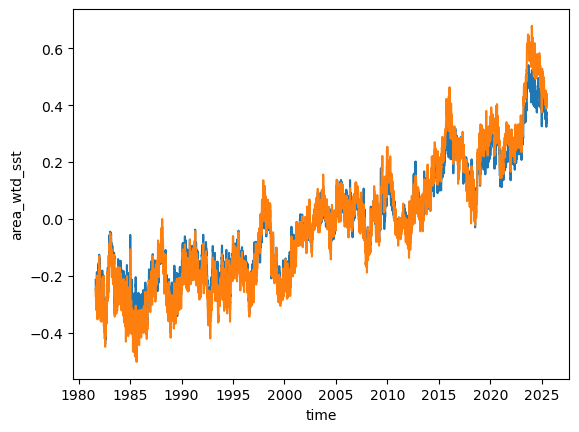

In [4]:
# Comparison Plot
mean_anomalies.sst.plot(label = "Global - Un-Weighted")
weighted_means.area_wtd_sst.plot(label = "Global - Area-Weighted")

## Convert To Table for Export

The next chunk drops the columns we don't need and joins the two time series into a single table for exporting it out.

In [5]:
# convert anomalies to a dataframe from xr.array
anom_df = mean_anomalies.sst.to_dataframe()
# Convert area-weighted anomalies to dataframe
anoms_wtd = weighted_means.area_wtd_sst.to_dataframe()

# Drop columns we don't need
anom_df = anom_df.drop(columns = ["MOD", "modified_ordinal_day"])
anoms_wtd  = anoms_wtd.drop(columns = ["MOD", "modified_ordinal_day"])

# Tail
anoms_wtd.tail()

,area_wtd_sst
time,
2025-06-11 12:00:00,0.414539
2025-06-12 12:00:00,0.421340
2025-06-13 12:00:00,0.431991
2025-06-14 12:00:00,0.440825
2025-06-15 12:00:00,0.430371


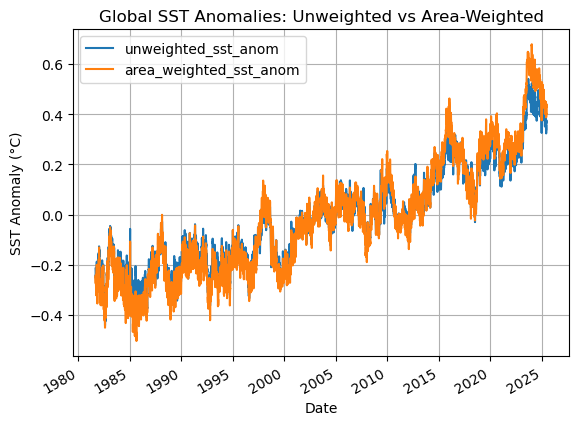

In [6]:
# Join them
combined_anoms = anom_df.join(anoms_wtd, lsuffix = "_unwtd", rsuffix = "_wtd")
combined_anoms.tail()

# Rename the columns
combined_anoms = combined_anoms.rename(columns = {"sst": "unweighted_sst_anom", "area_wtd_sst": "area_weighted_sst_anom"})

# Plot sst and area_wtd_sst together
combined_anoms.plot()
plt.legend()
plt.title("Global SST Anomalies: Unweighted vs Area-Weighted")
plt.ylabel("SST Anomaly (°C)")
plt.xlabel("Date")
plt.grid()
plt.show()  

In [8]:
# SAVING
# anom_df.to_csv(f"{box_root}Res_Data/OISST/oisst_mainstays/global_timeseries/global_anoms_1982to2011.csv") # Swapped to 1991-2020
anom_df.to_csv(f"{box_root}Res_Data/OISST/oisst_mainstays/global_timeseries/global_anoms_1991to2020.csv")

# Close the dataset
oisst_anomalies.close()

---

# Average Global Temps

Do the same steps but for raw temperature...

In [ ]:
# Load temps
start_yr = 1981
end_yr   = 2025
# Load OISSt using ot.load_box_oisst()
oisst = ot.load_box_oisst(
    box_root, 
    start_yr, 
    end_yr, 
    anomalies = False, 
    do_parallel = True)

## Timeline for global anomalies
# wonderful tool to calculate spatial mean by using dim variable names
mean_temps = oisst.mean(['lat', 'lon']) 

# Area Weighted Means
area_wtd_means = ot.area_weighted_means(oisst, var_name = "sst", sd = False)

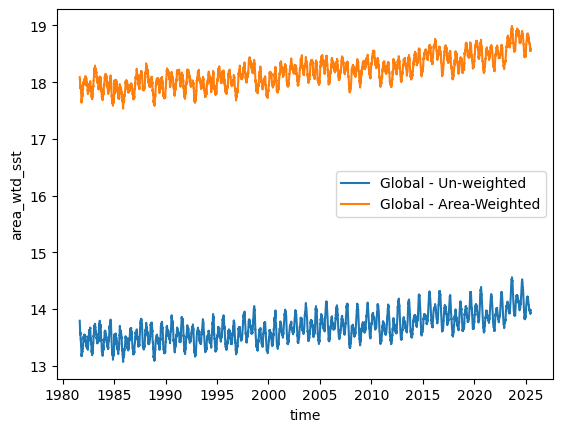

In [12]:
# # Plot each
# mean_temps.sst.plot(label = "Global - Un-weighted")
# area_wtd_means.area_wtd_sst.plot(label = "Global - Area-Weighted")
# plt.legend()

In [16]:
# convert ssts to a dataframe from xr.array
sst_df = mean_temps.sst.to_dataframe()

# Convert area-weighted anomalies to dataframe
sst_wtd = weighted_means.area_wtd_sst.to_dataframe()

# Drop columns we don't need
sst_wtd  = sst_wtd.drop(columns = ["MOD", "modified_ordinal_day"])

In [17]:
sst_df.tail()

,sst
time,
2025-06-11 12:00:00,13.949287
2025-06-12 12:00:00,13.958503
2025-06-13 12:00:00,13.972388
2025-06-14 12:00:00,13.984976
2025-06-15 12:00:00,13.981402


In [18]:
sst_wtd.tail()

,area_wtd_sst
time,
2025-06-11 12:00:00,0.414539
2025-06-12 12:00:00,0.421340
2025-06-13 12:00:00,0.431991
2025-06-14 12:00:00,0.440825
2025-06-15 12:00:00,0.430371


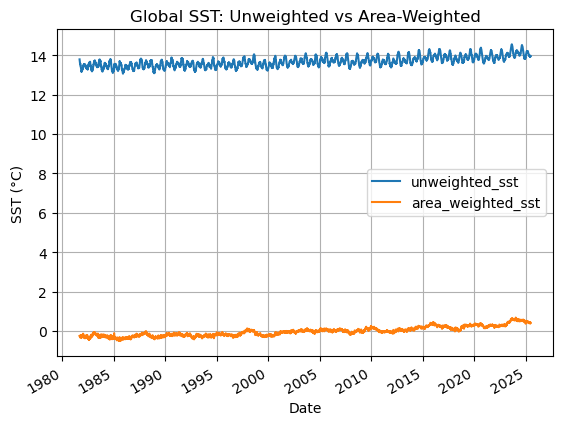

In [20]:
# Join them
combined_sst = sst_df.join(sst_wtd, lsuffix = "_unwtd", rsuffix = "_wtd")
combined_sst.tail()

# Rename the columns
combined_sst = combined_sst.rename(columns = {"sst": "unweighted_sst", "area_wtd_sst": "area_weighted_sst"})

# Plot sst and area_wtd_sst together
combined_sst.plot()
plt.legend()
plt.title("Global SST: Unweighted vs Area-Weighted")
plt.ylabel("SST (°C)")
plt.xlabel("Date")
plt.grid()
plt.show()  

In [21]:
# SAVING
combined_sst.to_csv(f"{box_root}Res_Data/OISST/oisst_mainstays/global_timeseries/global_temps_oisst.csv")